In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy.external as sce
import scanpy as sc
import anndata as an
import gget
import re
import rapids_singlecell as rsc

import warnings
warnings.filterwarnings("ignore")

sc.settings.verbosity = 3 

# Load Genes

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/lab_data/genes.raw.h5ad"
adata = sc.read_h5ad(fpath)
adata.layers['counts'] = adata.X.copy()
print(f"\tTotal UMIs: {int(np.sum(adata.X))}")
print(f"\tCells: {adata.shape[0]}")
print(f"\tGenes: {adata.shape[1]}")
print()
adata

	Total UMIs: 334403436
	Cells: 31261
	Genes: 30032

CPU times: user 449 ms, sys: 1.42 s, total: 1.87 s
Wall time: 3.82 s


AnnData object with n_obs × n_vars = 31261 × 30032
    obs: 'dataset'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'
    layers: 'counts'

# Load in cell cycle predictions

In [3]:
label = "cell_cycle_"
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/sc_fib_tsb_rerun/feature_barcodes/fbc_map.csv"
df = pd.read_csv(fpath)

conditions = set([x for x in df.columns.str.replace(r'^chunk_\d+_', '', regex=True)])
conditions.discard('pred')
conditions.discard('cell_barcode')
conditions = list(conditions)

for condition in conditions:
    print(f"summing over {condition}")
    df[condition] = df.loc[:, df.columns.str.endswith(condition)].sum(axis=1)

df = df[['cell_barcode'] + conditions]
# identify most likely feature for each cell
df = df.groupby('cell_barcode', as_index=False).sum()
df['feature'] = df[conditions].idxmax(axis=1)
df['cell_barcode'] = label + df['cell_barcode'] + "-1"

print(f"{df.shape=}")
barcode_map = dict(zip(df['cell_barcode'].values, df['feature'].values))

# merge into adata
adata.obs['barcoded_phase'] = adata.obs.index.map(barcode_map)
print(adata.obs['barcoded_phase'].value_counts(dropna=False).to_string())

summing over G1
summing over S
summing over G2M
df.shape=(10715, 5)
barcoded_phase
NaN    22386
G1      5733
S       1689
G2M     1453


# Load in the Hybrid Barcodes

In [4]:
label = "hybrid_"
fpath = "/scratch/indikar_root/indikar1/shared_data/library_2_tsb_strict/feature_barcodes/fbc_map.csv"
df = pd.read_csv(fpath)

conditions = set([x for x in df.columns.str.replace(r'^chunk_\d+_', '', regex=True)])
conditions.discard('pred')
conditions.discard('cell_barcode')
conditions = list(conditions)

for condition in conditions:
    print(f"summing over {condition}")
    if condition == 'MYOD':
        df[condition] = df.loc[:, df.columns.str.endswith(condition) & ~df.columns.str.contains('P')].sum(axis=1)
    else:
        df[condition] = df.loc[:, df.columns.str.endswith(condition)].sum(axis=1)

df = df[['cell_barcode'] + conditions]
# identify most likely phase
df = df.groupby('cell_barcode', as_index=False).sum()
df['feature'] = df[conditions].idxmax(axis=1)
df['cell_barcode'] = label + df['cell_barcode'] + "-1"

print(f"{df.shape=}")
barcode_map = dict(zip(df['cell_barcode'].values, df['feature'].values))

# merge into adata
adata.obs['barcoded_condition'] = adata.obs.index.map(barcode_map)
print(adata.obs['barcoded_condition'].value_counts(dropna=False).to_string())

summing over PRRX1
summing over PRRX1_MYOD
summing over MYOD
df.shape=(11639, 5)
barcoded_condition
NaN           20367
PRRX1_MYOD     4283
PRRX1          3993
MYOD           2618


# Cell Cycle Phase Prediction

In [5]:
cell_cycle_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]

print(f"N S genes: {len(s_genes)}")
print(f"N G2M genes: {len(g2m_genes)}")

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

N S genes: 42
N G2M genes: 52
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    377 total control genes are used. (0:00:02)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    292 total control genes are used. (0:00:02)
-->     'phase', cell cycle phase (adata.obs)


# QC + Preprocessing 

In [6]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

rsc.get.anndata_to_CPU(adata)

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_counts=10)

min_n_genes = 1000
adata = adata[adata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()

rsc.get.anndata_to_GPU(adata) # move to GPU
adata

filtered out 3567 cells that have less than 500 counts
filtered out 3256 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 26021 × 26776
    obs: 'dataset', 'barcoded_phase', 'barcoded_condition', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'log1p'
    layers: 'counts', 'log_norm'

In [7]:
print(adata.obs['dataset'].value_counts().to_string())

dataset
hybrid        10153
hsc            8326
cell_cycle     7542


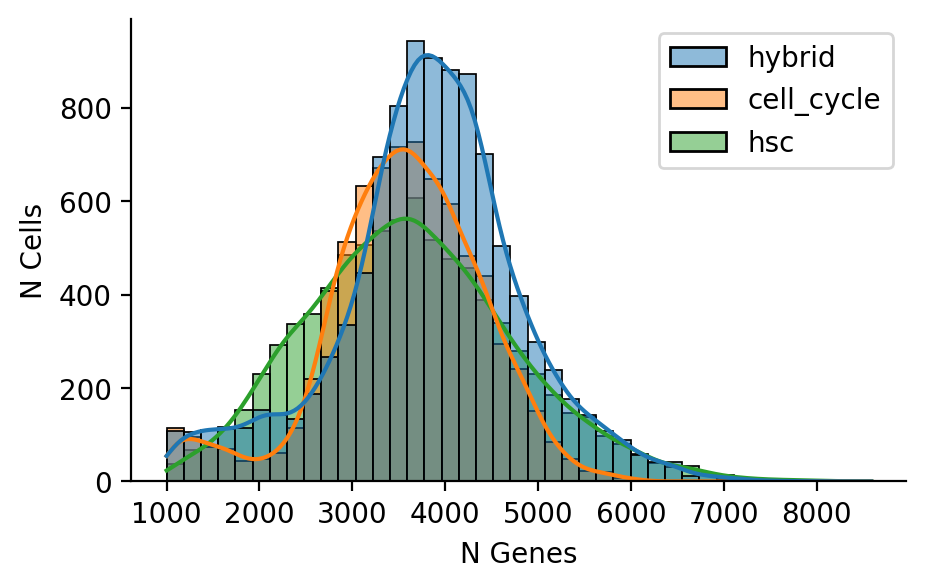

In [8]:
adata.obs['n_genes'] = adata.obs['n_genes_by_counts']

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.histplot(
    data=adata.obs,
    bins=41,
    x='n_genes',
    hue='dataset',
    kde=True,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
)
plt.ylabel('N Cells')
plt.xlabel('N Genes')

sns.despine()

Number of genes before HVG selection: 26776
Number of HVG: 2750


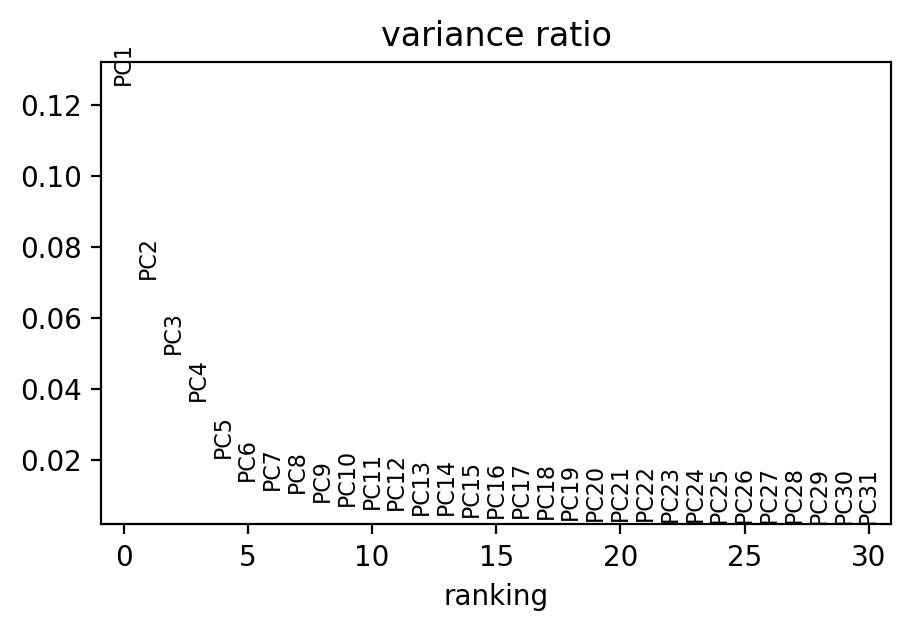

AnnData object with n_obs × n_vars = 26021 × 26776
    obs: 'dataset', 'barcoded_phase', 'barcoded_condition', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'log_norm'

In [9]:
print(f"Number of genes before HVG selection: {adata.n_vars}")

rsc.pp.highly_variable_genes(
    adata, 
    batch_key='dataset',
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

rsc.pp.pca(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3
sc.pl.pca_variance_ratio(adata)

adata

[2025-05-13 17:05:36.294] [CUML] [debug] n_neighbors=155
[2025-05-13 17:05:36.295] [CUML] [debug] Calling knn graph run
[2025-05-13 17:05:36.295] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-13 17:05:36.329] [CUML] [debug] Done. Calling remove zeros


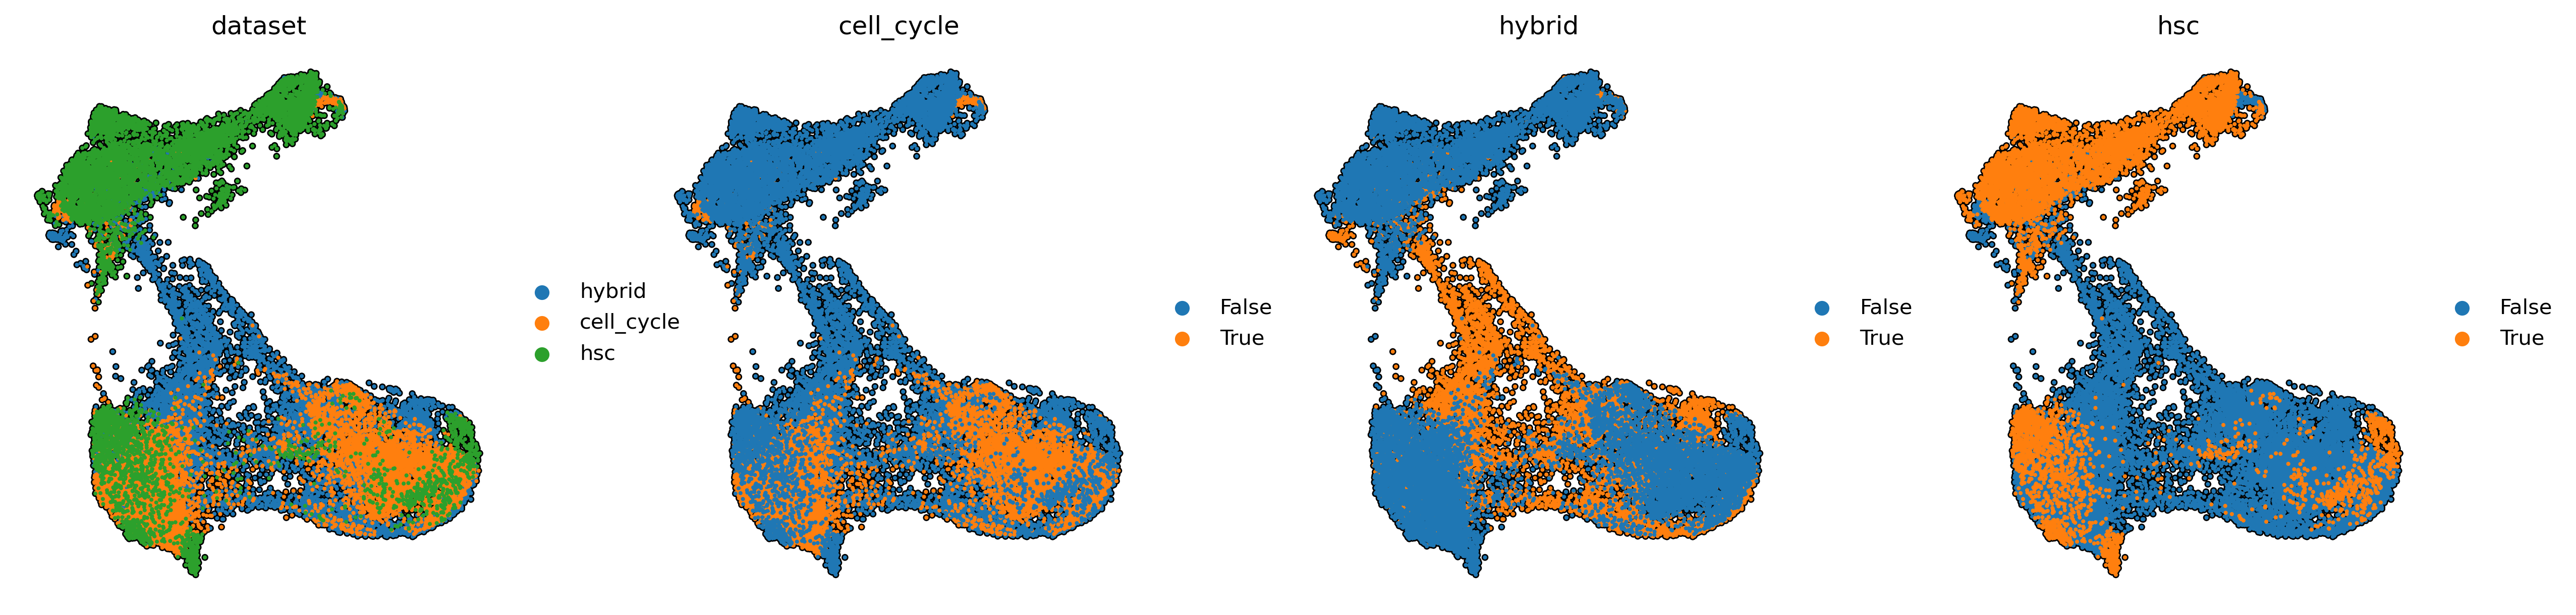

In [10]:
rsc.pp.harmony_integrate(adata, 'dataset')

rsc.pp.neighbors(
    adata,
    n_neighbors=155,
    use_rep='X_pca_harmony',
)

rsc.tl.umap(
    adata, 
    min_dist=0.2,
)

for val in adata.obs['dataset'].unique():
    adata.obs[val] = adata.obs['dataset'] == val

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.umap(
    adata, 
    color=["dataset", 'cell_cycle', 'hybrid', 'hsc'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
)

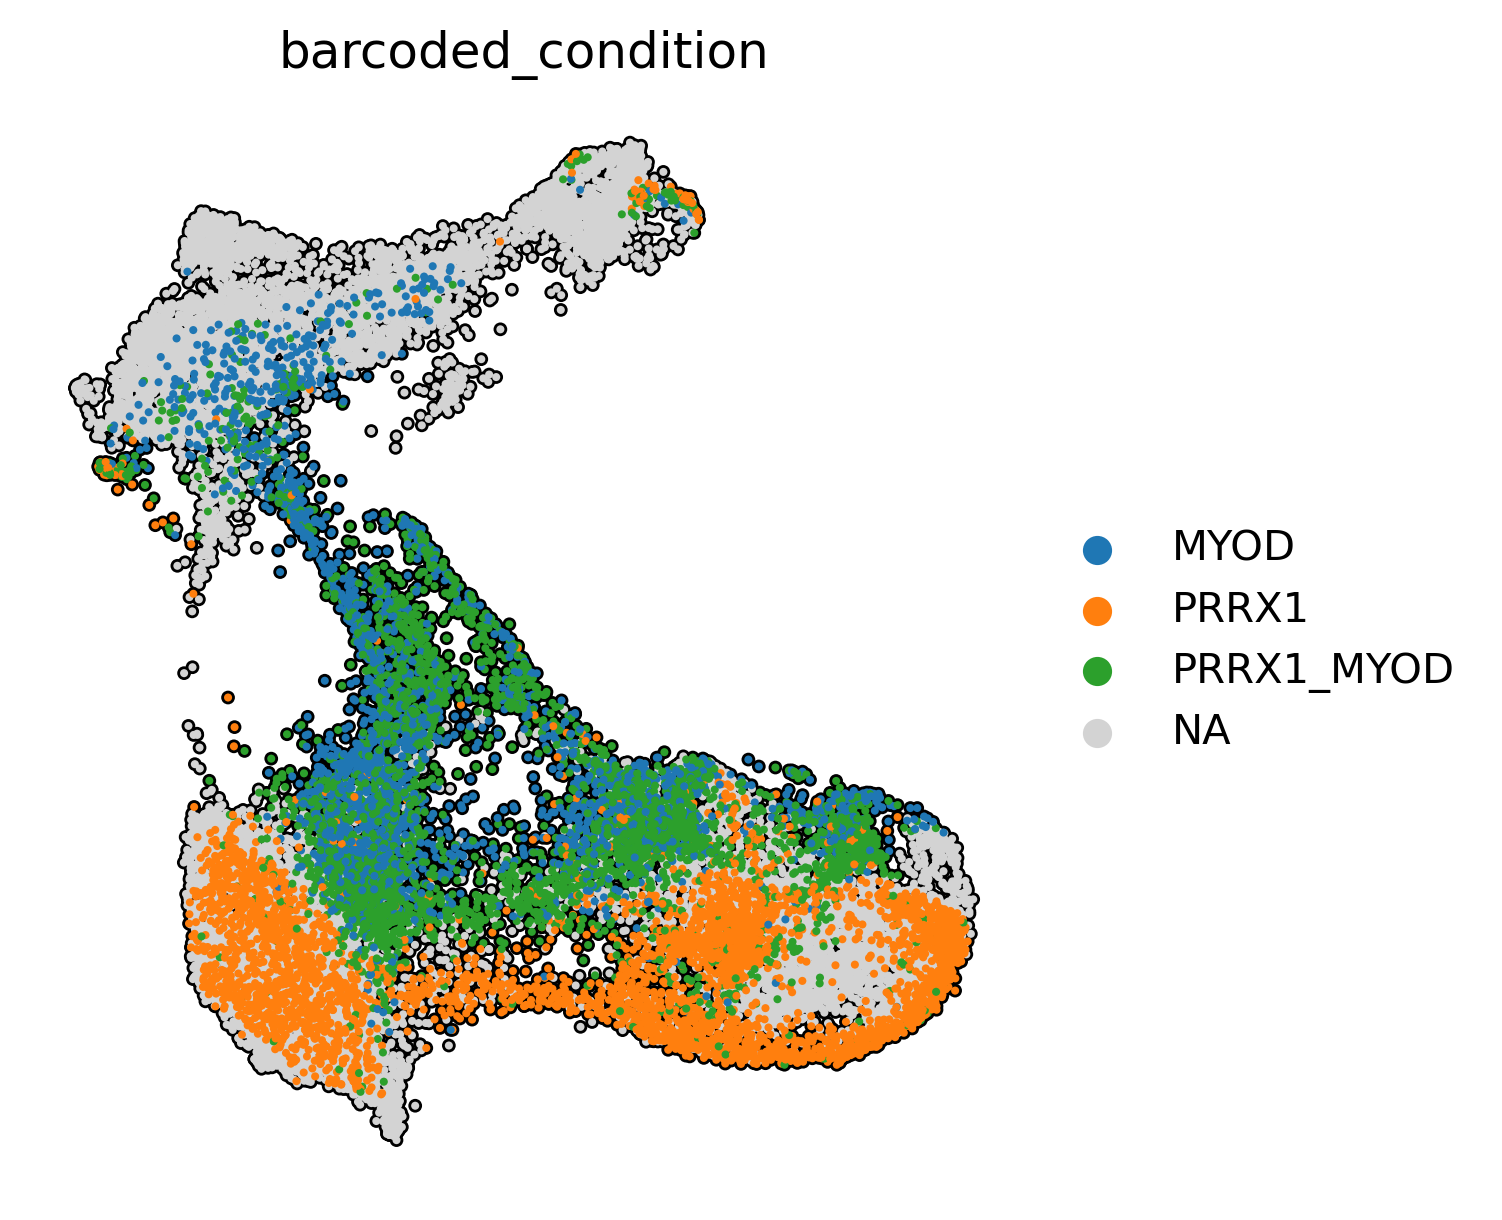

In [11]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.umap(
    adata, 
    color=['barcoded_condition'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)

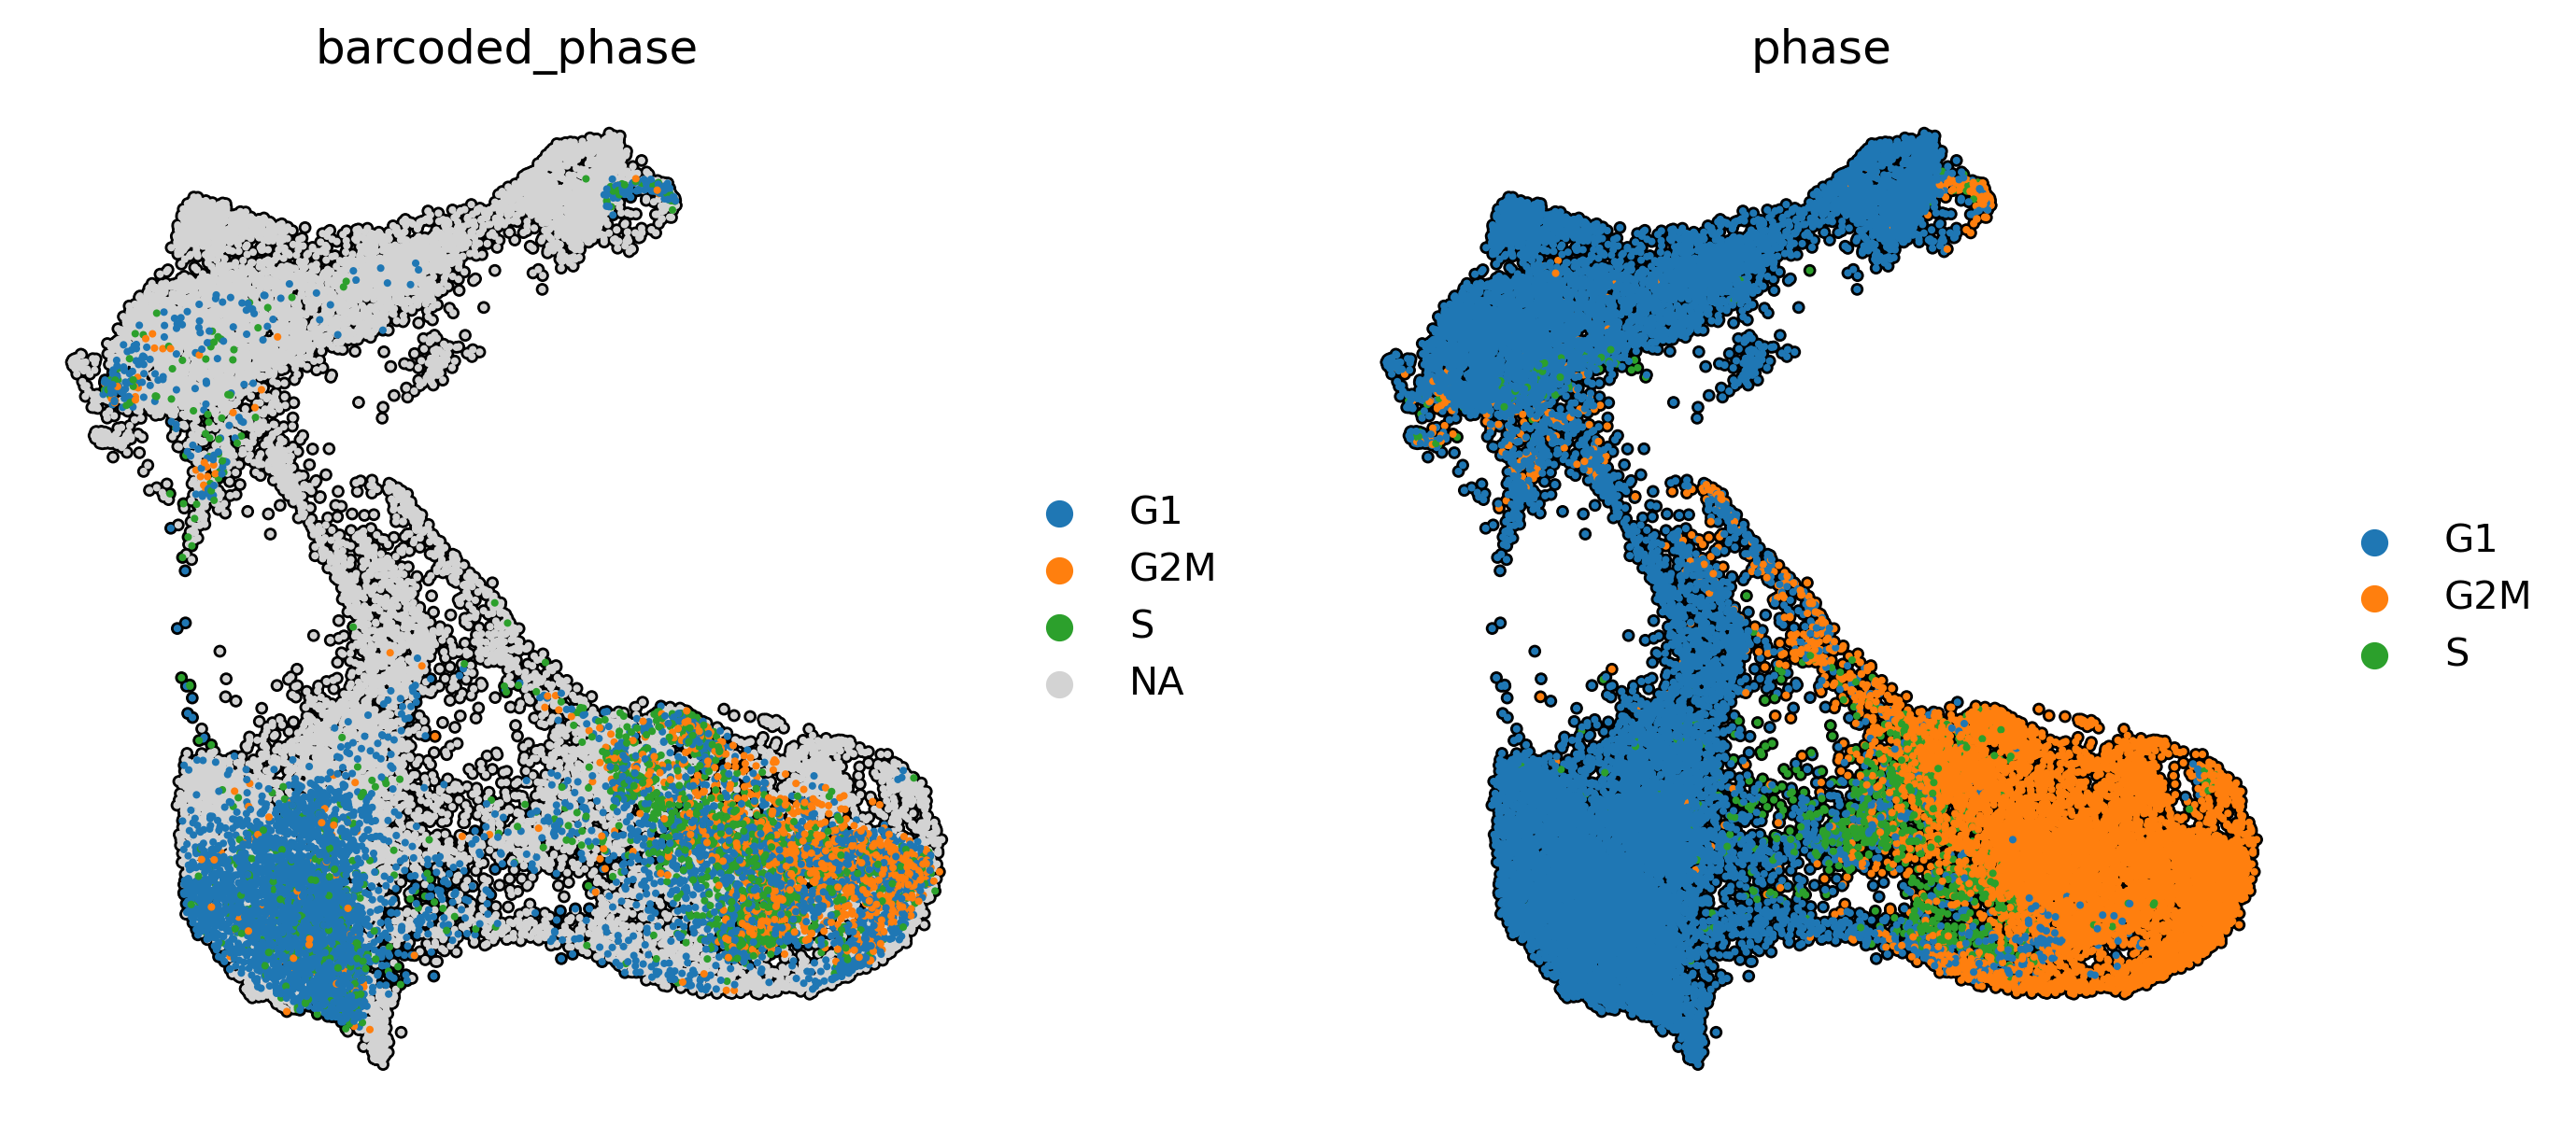

In [12]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.umap(
    adata, 
    color=['barcoded_phase', 'phase'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)

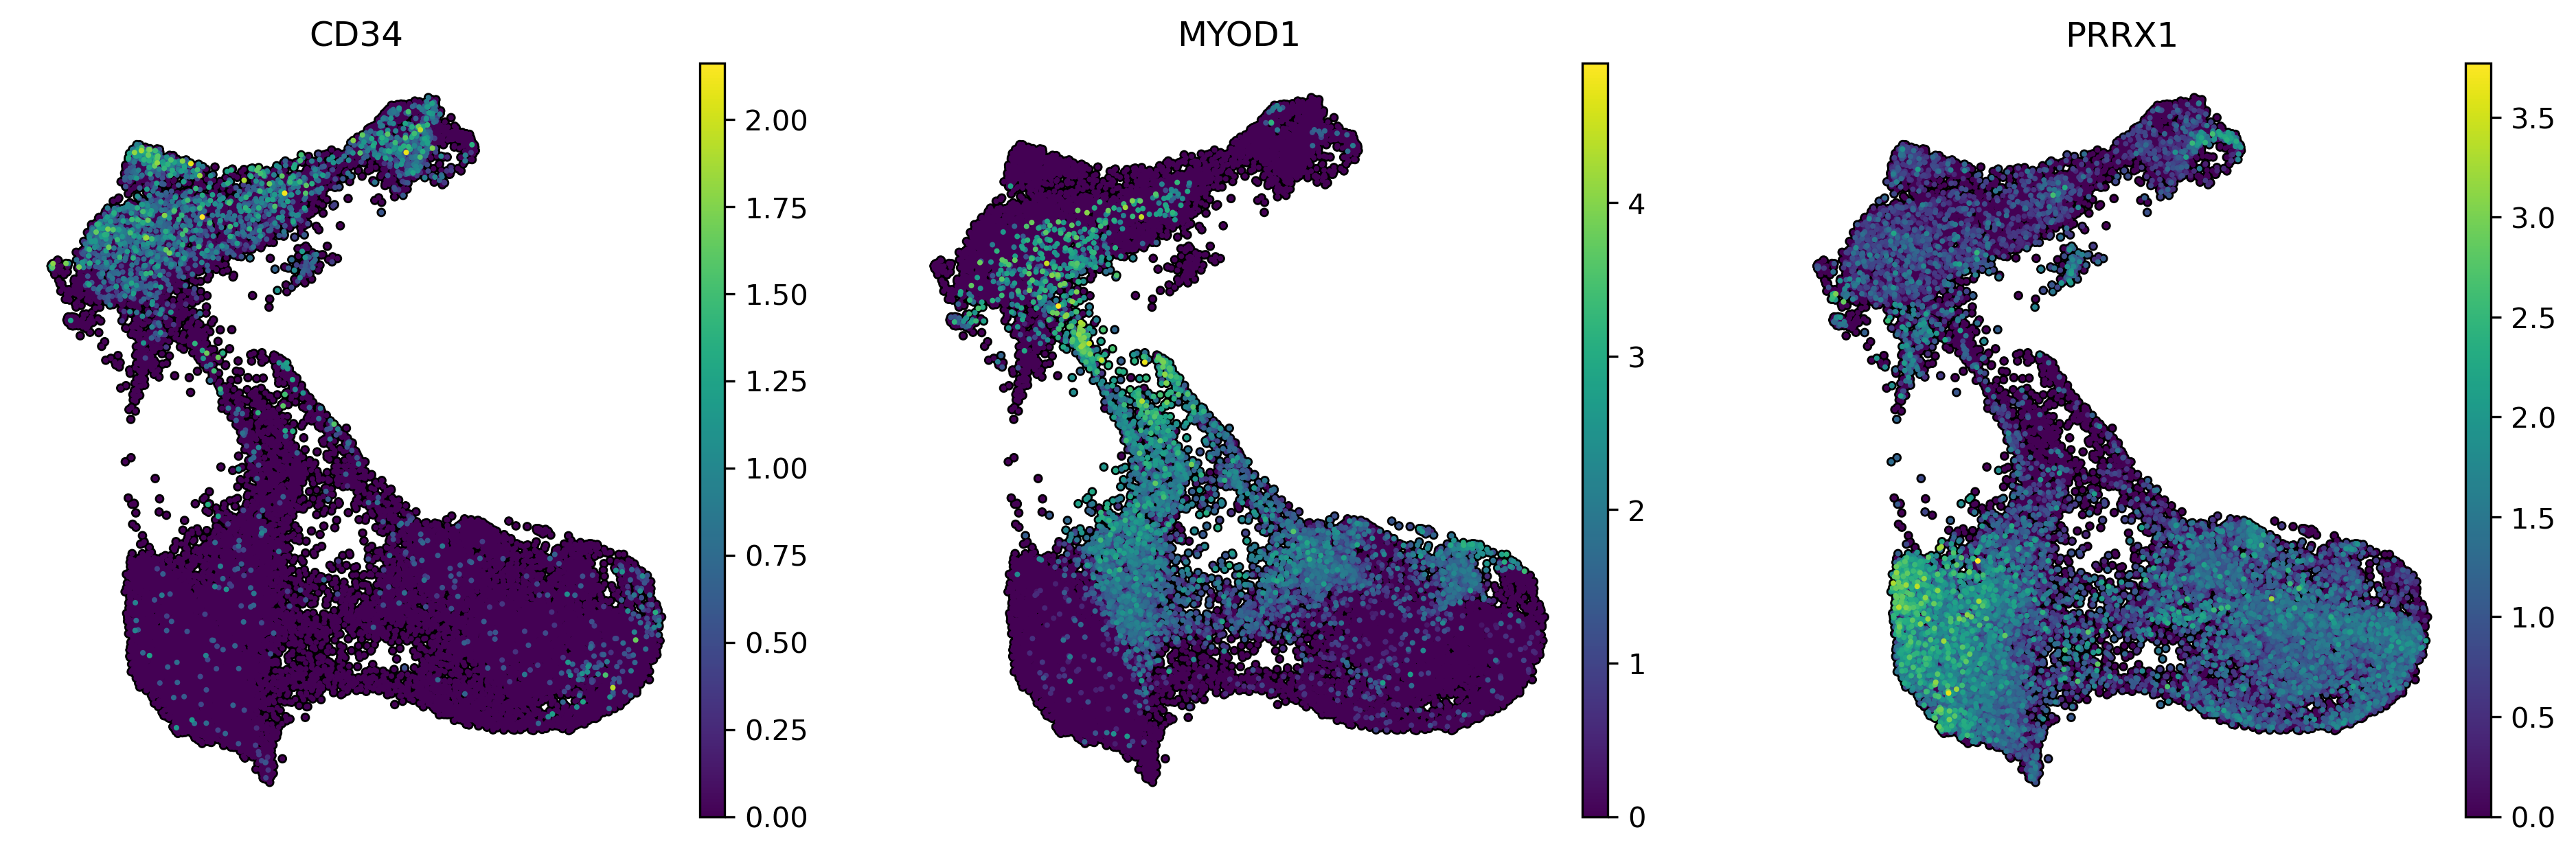

In [13]:
rsc.get.anndata_to_CPU(adata)
sc.pl.umap(
    adata, 
    color=["CD34", "MYOD1", "PRRX1"],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
)


# Load Transcripts

In [14]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/lab_data/transcripts.raw.h5ad"
bdata = sc.read_h5ad(fpath)
print(f"Raw cells: {bdata.shape[0]}")

# filter out cells that don't pass QC in gene expression
bdata = bdata[adata.obs_names, :].copy()
print(f"Filtered cells: {bdata.shape[0]}")

# filter out transcripts with insufficient expression
sc.pp.filter_genes(bdata, min_counts=10)

bdata

Raw cells: 30819
Filtered cells: 26021
filtered out 23052 genes that are detected in less than 10 counts
CPU times: user 934 ms, sys: 1.84 s, total: 2.78 s
Wall time: 4.13 s


AnnData object with n_obs × n_vars = 26021 × 85608
    obs: 'dataset'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'n_counts'

In [15]:
# Merge in gene expression aggregates from adata
X = adata.layers['counts']

means = np.asarray(X.mean(axis=0)).ravel()
sums = np.asarray(X.sum(axis=0)).ravel()
stds = np.sqrt(X.multiply(X).mean(axis=0).A1 - means**2)

gdf = pd.DataFrame({
    'gene_mean': means,
    'gene_sum': sums,
    'gene_name': adata.var_names
}, index=adata.var_names)

# Merge onto bdata.var
X = bdata.X
bvar = bdata.var.copy()
bvar['transcript_sum'] = np.asarray(X.sum(axis=0)).ravel()
bvar['transcript_mean'] = np.asarray(X.mean(axis=0)).ravel()
bvar = bvar.reset_index()

bvar = bvar.merge(
    gdf.set_index('gene_name'),
    on='gene_name',
    how='left'
).set_index('transcript_name')

bdata.var = bvar
bdata.var.head()

,index,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,n_counts,transcript_sum,transcript_mean,gene_mean,gene_sum
transcript_name,,,,,,,,,,,,,
ARF5-201,ENST00000000233,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,23767.0,23767.0,0.913378,0.976404,25407.0
M6PR-201,ENST00000000412,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,6809.0,6809.0,0.261673,0.468891,12201.0
ESRRA-201,ENST00000000442,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,407.0,407.0,0.015641,0.045771,1191.0
FKBP4-201,ENST00000001008,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,4546.0,4546.0,0.174705,0.190385,4954.0
NDUFAF7-201,ENST00000002125,ENSG00000003509,NDUFAF7,protein_coding,protein_coding,chr2,37231657,37249160,952.0,952.0,0.036586,0.090888,2365.0


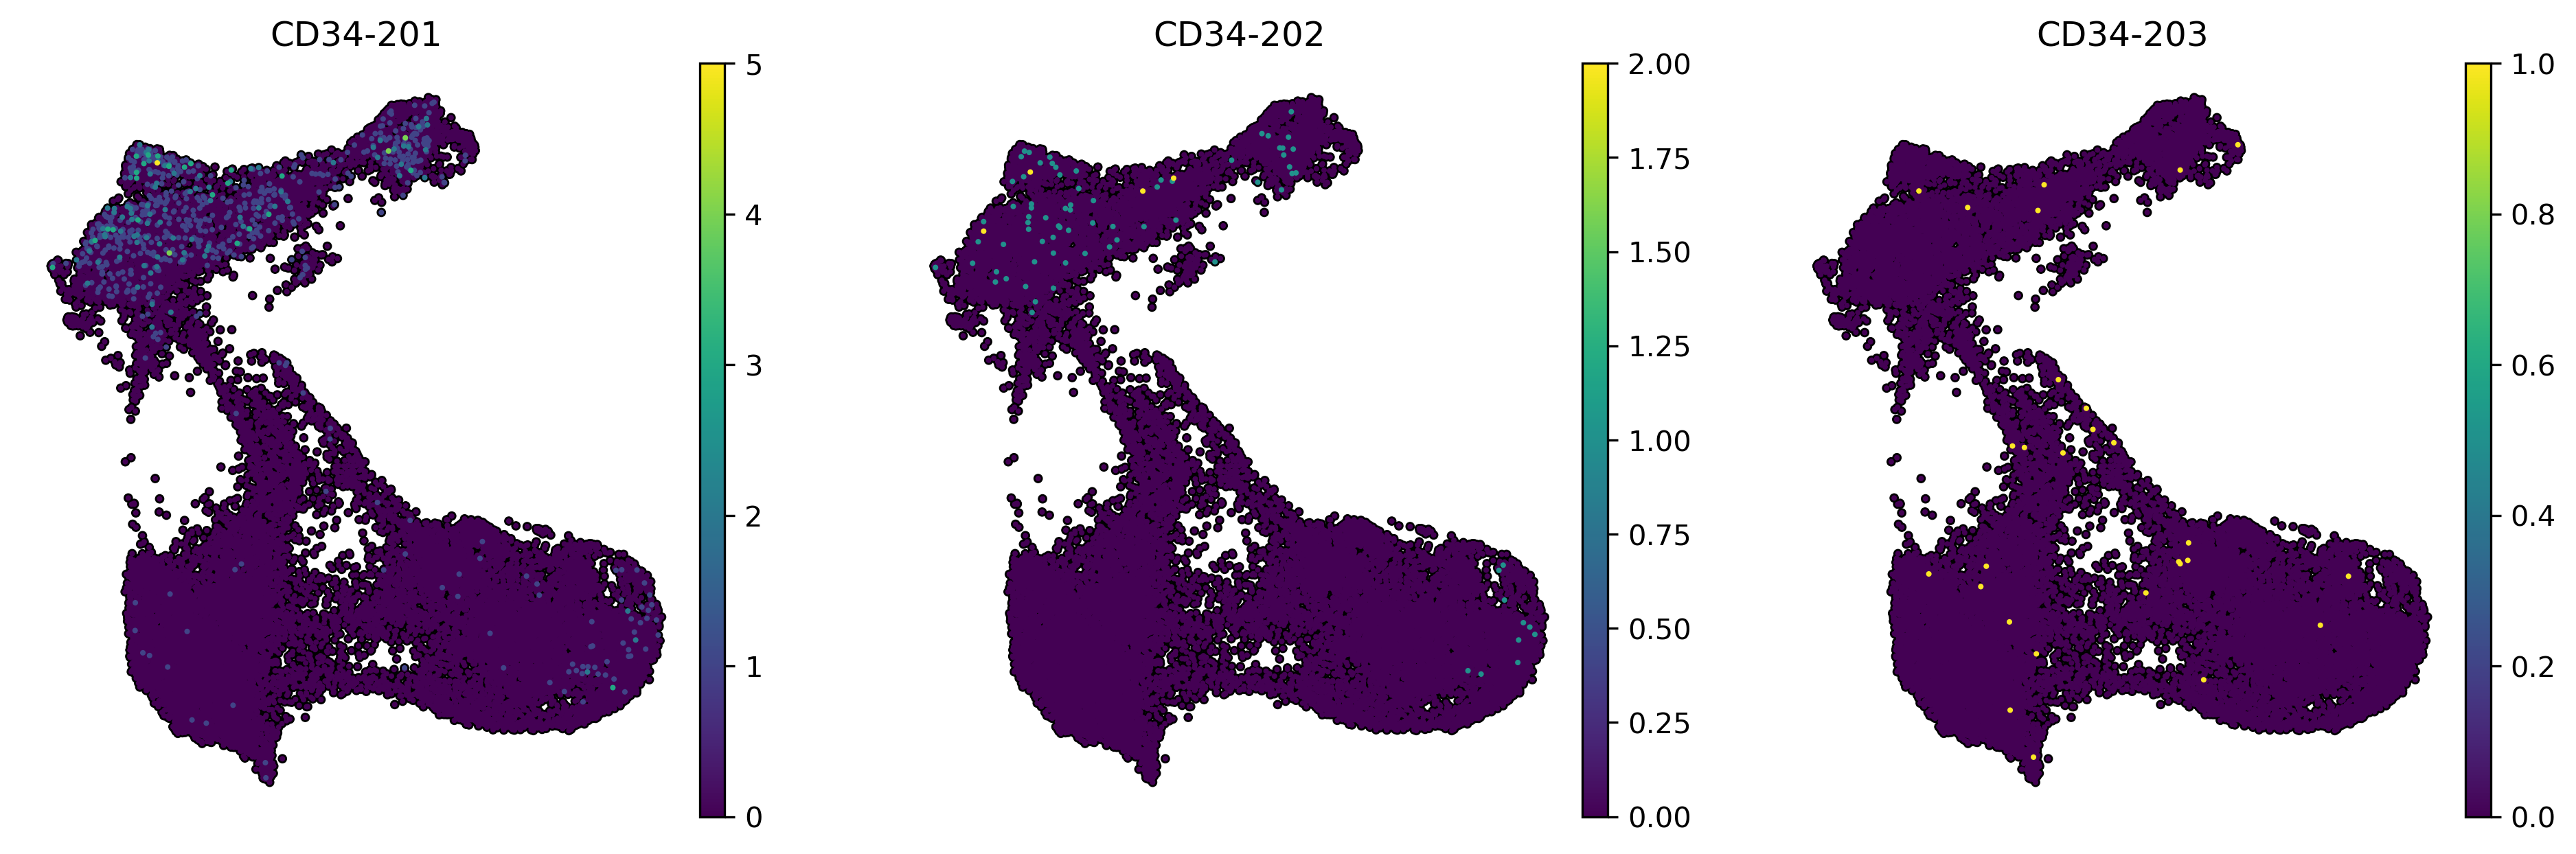

In [16]:
# Merge in UMAP coords
assert(bdata.obs_names == adata.obs_names).all() # make sure data is in the same order
bdata.obsm['X_umap'] = adata.obsm['X_umap'].copy()

gene_query = 'CD34'

transcript_names = bdata.var[bdata.var['gene_name'] == gene_query].index

sc.pl.umap(
    bdata, 
    color=transcript_names,
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
)

In [17]:
# merge in obs
assert(bdata.obs_names == adata.obs_names).all() # make sure data is in the same order
bdata.obs = adata.obs.copy()

# Write to file

In [18]:
%%time

# Write gene-level AnnData
outpath = "/nfs/turbo/umms-indikar/shared/projects/lab_data/genes.processed.h5ad"
print(f"Writing gene-level AnnData to: {outpath}")
adata.write(outpath)

# Write transcript-level AnnData
outpath = "/nfs/turbo/umms-indikar/shared/projects/lab_data/transcripts.processed.h5ad"
print(f"Writing transcript-level AnnData to: {outpath}")
bdata.write(outpath)

print('done!')

Writing gene-level AnnData to: /nfs/turbo/umms-indikar/shared/projects/lab_data/genes.processed.h5ad
Writing transcript-level AnnData to: /nfs/turbo/umms-indikar/shared/projects/lab_data/transcripts.processed.h5ad
done!
CPU times: user 929 ms, sys: 2.43 s, total: 3.36 s
Wall time: 15.6 s
